# Delay Prediction (Modèle LightGBM en cascade)

---

## Pourquoi LightGBM ?

**LightGBM** est un algorithme de boosting par gradient (GBDT) conçu pour la vitesse et la performance.  
Contrairement au BRF qui under-sample à chaque arbre, LightGBM gère le déséquilibre via :
- `scale_pos_weight` : pondère la classe minoritaire
- `class_weight` : poids inversement proportionnels à la fréquence
- `is_unbalance=True` : mode natif déséquilibre

### Architecture identique : Cascade ordonnée à 3 étapes binaires

```
Étape 1 — LGBM Binaire : Retard > 5 min ?       
Étape 2 — LGBM Binaire : Parmi >5min, >30min ?  
Étape 3 — LGBM Binaire : Parmi >30min, >60min ?
```

### Règles métier (Système NS — Pays-Bas)

| Classe | Retard | Action | Compensation |
|---|---|---|---|
| 0 | ≤ 5 min | Rien | — |
| 1 | 5–30 min | Alertes passagers | — |
| 2 | 30–60 min | Compensation légale | **50% du prix du billet** |
| 3 | > 60 min | Compensation légale | **100% du prix du billet** |

---
## 1. Imports & Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score,
    precision_recall_curve, average_precision_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder

try:
    import lightgbm as lgb
    print(f'✓ LightGBM disponible (version {lgb.__version__})')
except ImportError:
    raise ImportError('Installe LightGBM : pip install lightgbm')

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print('✓ SMOTE disponible (optionnel étape 2)')
except ImportError:
    SMOTE_AVAILABLE = False
    print('  SMOTE non disponible — étape 2 sans SMOTE')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13, 'axes.labelsize': 11})
PALETTE = sns.color_palette('muted')

print('\nImports OK.')

✓ LightGBM disponible (version 4.6.0)
✓ SMOTE disponible (optionnel étape 2)

Imports OK.


---
## 2. Chargement et Prétraitement

In [6]:
chunks = []
for chunk in pd.read_csv('df_clean.csv', chunksize=50_000, low_memory=False):
    chunks.append(chunk)
df_clean = pd.concat(chunks, ignore_index=True)
print(f'Chargé : {df_clean.shape[0]:,} lignes × {df_clean.shape[1]} colonnes')

df_clean['Service:Date']        = pd.to_datetime(df_clean['Service:Date'], errors='coerce')
df_clean['Stop:Departure time'] = pd.to_datetime(df_clean['Stop:Departure time'], utc=True, errors='coerce')
df_clean['Stop:Arrival time']   = pd.to_datetime(df_clean['Stop:Arrival time'],   utc=True, errors='coerce')
df_clean['dep_hour'] = df_clean['Stop:Departure time'].dt.tz_convert('Europe/Amsterdam').dt.hour

for col in ['Stop:Platform change','Service:Completely cancelled','Service:Partly cancelled',
            'Stop:Arrival cancelled','Stop:Departure cancelled']:
    if col in df_clean.columns:
        df_clean[col] = (df_clean[col].astype(str).str.strip().str.lower()
                         .map({'true':1,'false':0,'1':1,'0':0}).fillna(0).astype(int))

df_clean['Service:Maximum delay'] = pd.to_numeric(df_clean['Service:Maximum delay'], errors='coerce')
print('Prétraitement OK.')

Chargé : 21,838,516 lignes × 17 colonnes
Prétraitement OK.


---
## 3. Estimation du Prix du Billet par Service

Le prix d'un billet NS varie selon la durée du trajet.  
Après analyse des tarifs officiels NS 2024, nous avons estimé un prix moyen du billet pour chaque tranche de durée de service:

| Durée du service | Prix estimé |
|---|---|
| < 15 min (trajet très court) | €5 |
| 15–30 min | €8 |
| 30–60 min | €14 |
| 60–90 min | €22 |
| 90–120 min | €30 |
| > 120 min | €40 |

> **Note** : La durée du service = (heure d'arrivée au dernier stop) - (heure de départ au premier stop).  
> Le prix est estimé **par service** (trajet complet), pas par stop individuel.

═════════════════════════════════════════════════════════════════
  DISTRIBUTION DES PRIX DE BILLETS ESTIMÉS (par service)
═════════════════════════════════════════════════════════════════
  €    5  →   300,297 services  ( 14.6%)
  €    8  →   388,655 services  ( 18.8%)
  €   14  →   743,298 services  ( 36.0%)
  €   22  →   260,275 services  ( 12.6%)
  €   30  →   172,842 services  (  8.4%)
  €   40  →   197,895 services  (  9.6%)
─────────────────────────────────────────────────────────────────
  Prix moyen  : €16.40
  Prix médian : €14.00
  Durée moy.  : 53.9 min
═════════════════════════════════════════════════════════════════


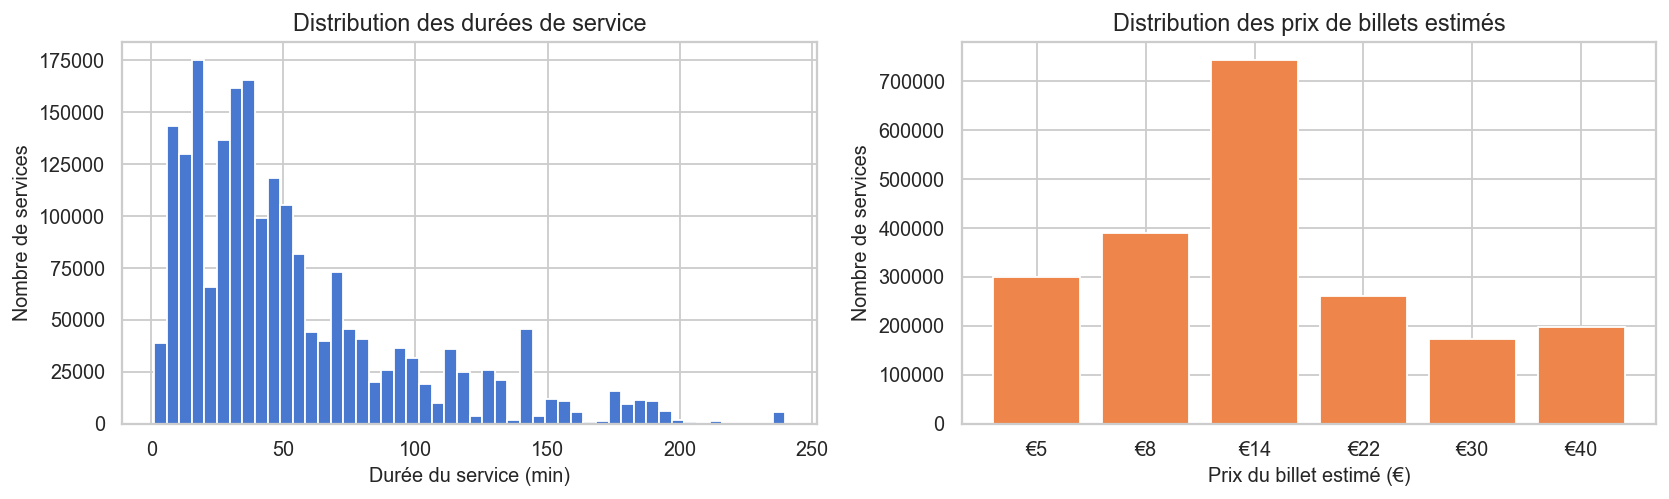

In [ ]:
df_times = df_clean[['Service:RDT-ID', 'Stop:Departure time', 'Stop:Arrival time']].copy()
df_times = df_times.dropna(subset=['Stop:Departure time', 'Stop:Arrival time'])

df_service_duration = df_times.groupby('Service:RDT-ID').agg(
    first_dep = ('Stop:Departure time', 'min'),
    last_arr  = ('Stop:Arrival time',   'max')
).reset_index()

df_service_duration['service_duration_min'] = (
    (df_service_duration['last_arr'] - df_service_duration['first_dep'])
    .dt.total_seconds() / 60
)

df_service_duration = df_service_duration[
    (df_service_duration['service_duration_min'] > 0) &
    (df_service_duration['service_duration_min'] < 480)
].copy()

def estimate_ticket_price(duration_min):
    """
    Estimation du prix d'un billet NS (2ème classe, 1 personne)
    basée sur la durée totale du service. Source : tarifs NS 2024.
    """
    if pd.isna(duration_min):
        return 14.0
    elif duration_min < 15:  return 5.0
    elif duration_min < 30:  return 8.0
    elif duration_min < 60:  return 14.0
    elif duration_min < 90:  return 22.0
    elif duration_min < 120: return 30.0
    else:                    return 40.0

df_service_duration['ticket_price_eur'] = (
    df_service_duration['service_duration_min'].apply(estimate_ticket_price)
)

print('═'*65)
print('  DISTRIBUTION DES PRIX DE BILLETS ESTIMÉS (par service)')
print('═'*65)
price_dist = df_service_duration['ticket_price_eur'].value_counts().sort_index()
for price, cnt in price_dist.items():
    pct = cnt / len(df_service_duration) * 100
    print(f'  €{price:>5.0f}  →  {cnt:>8,} services  ({pct:5.1f}%)')
print('─'*65)
print(f'  Prix moyen  : €{df_service_duration["ticket_price_eur"].mean():.2f}')
print(f'  Prix médian : €{df_service_duration["ticket_price_eur"].median():.2f}')
print(f'  Durée moy.  : {df_service_duration["service_duration_min"].mean():.1f} min')
print('═'*65)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_service_duration['service_duration_min'].clip(0, 240),
             bins=50, color=PALETTE[0], edgecolor='white')
axes[0].set_xlabel('Durée du service (min)')
axes[0].set_ylabel('Nombre de services')
axes[0].set_title('Distribution des durées de service')
axes[1].bar([f'€{p:.0f}' for p in price_dist.index],
            price_dist.values, color=PALETTE[1], edgecolor='white')
axes[1].set_xlabel('Prix du billet estimé (€)')
axes[1].set_ylabel('Nombre de services')
axes[1].set_title('Distribution des prix de billets estimés')
plt.tight_layout()
plt.savefig('lgbm_ticket_price_distribution.png', bbox_inches='tight')
plt.show()

---
## 4. Feature Engineering & Agrégation

In [ ]:
df_first = (
    df_clean.sort_values(['Service:RDT-ID','Stop:Departure time'], na_position='last')
    .groupby('Service:RDT-ID', as_index=False).first()
    [['Service:RDT-ID','Service:Date','Service:Type','Service:Company',
      'Service:Maximum delay','Service:Completely cancelled',
      'Service:Partly cancelled','dep_hour']]
)
df_last = (
    df_clean.sort_values(['Service:RDT-ID','Stop:Departure time'], na_position='last')
    .groupby('Service:RDT-ID', as_index=False).last()
    [['Service:RDT-ID','Stop:Station name']]
    .rename(columns={'Stop:Station name': 'last_station'})
)
df_agg = (
    df_clean.groupby('Service:RDT-ID').agg(
        n_stops              = ('Stop:RDT-ID',             'count'),
        platform_change_rate = ('Stop:Platform change',    'mean'),
        n_platform_changes   = ('Stop:Platform change',    'sum'),
        any_arr_cancelled    = ('Stop:Arrival cancelled',  'max'),
        any_dep_cancelled    = ('Stop:Departure cancelled','max'),
        n_cancelled_stops    = ('Stop:Arrival cancelled',  'sum'),
        first_station        = ('Stop:Station name',       'first'),
    ).reset_index()
)

df_service = df_first.merge(df_agg, on='Service:RDT-ID', how='left')
df_service = df_service.merge(df_last, on='Service:RDT-ID', how='left')

df_service = df_service.merge(
    df_service_duration[['Service:RDT-ID', 'service_duration_min', 'ticket_price_eur']],
    on='Service:RDT-ID', how='left'
)
df_service['ticket_price_eur']      = df_service['ticket_price_eur'].fillna(14.0)
df_service['service_duration_min']  = df_service['service_duration_min'].fillna(
    df_service['service_duration_min'].median()
)

df_service['Service:Date'] = pd.to_datetime(df_service['Service:Date'])
df_service['month']        = df_service['Service:Date'].dt.month
df_service['day_of_week']  = df_service['Service:Date'].dt.dayofweek
df_service['week']         = df_service['Service:Date'].dt.isocalendar().week.astype(int)
df_service['quarter']      = df_service['Service:Date'].dt.quarter
df_service['is_weekend']   = (df_service['day_of_week'] >= 5).astype(int)
df_service['is_peak_hour'] = (df_service['dep_hour'].between(7,9) | df_service['dep_hour'].between(16,19)).astype(int)
df_service['is_monday']    = (df_service['day_of_week'] == 0).astype(int)
df_service['is_friday']    = (df_service['day_of_week'] == 4).astype(int)
df_service['is_night']     = (df_service['dep_hour'].between(22,23) | df_service['dep_hour'].between(0,5)).astype(int)
df_service['winter_month'] = df_service['month'].isin([11,12,1,2]).astype(int)

for col, new_col in [('Service:Type','Service_Type_enc'),
                     ('Service:Company','Service_Company_enc'),
                     ('first_station','first_station_enc'),
                     ('last_station','last_station_enc')]:
    le = LabelEncoder()
    df_service[new_col] = le.fit_transform(df_service[col].astype(str).fillna('UNK'))

df_service['peak_x_weekday']           = df_service['is_peak_hour'] * (1 - df_service['is_weekend'])
df_service['long_route']               = (df_service['n_stops'] > df_service['n_stops'].median()).astype(int)
df_service['has_cancellation']         = (
    (df_service['Service:Completely cancelled'] == 1) |
    (df_service['Service:Partly cancelled'] == 1)
).astype(int)
df_service['cancel_severity']          = (
    df_service['Service:Completely cancelled'] * 3 +
    df_service['Service:Partly cancelled'] * 2 +
    df_service['any_arr_cancelled'] +
    df_service['any_dep_cancelled']
)
df_service['Svc_completely_cancelled'] = df_service['Service:Completely cancelled']
df_service['Svc_partly_cancelled']     = df_service['Service:Partly cancelled']

print(f'Dataset services : {df_service.shape[0]:,} services × {df_service.shape[1]} colonnes')
print(f'Prix moyen des billets : €{df_service["ticket_price_eur"].mean():.2f}')

Dataset services : 2,395,636 services × 38 colonnes
Prix moyen des billets : €16.07


---
## 5. Features Historiques + Split Temporel

Calculées **uniquement sur le train set**

In [ ]:
CLASS_LABELS = {
    0: 'À l\'heure (≤5min)',
    1: 'Mineur (5–30min)',
    2: 'Comp. 50% (30–60min)',
    3: 'Comp. 100% (>60min)'
}

def classify_delay(d):
    if pd.isna(d): return np.nan
    if d <= 5:    return 0
    elif d <= 30: return 1
    elif d <= 60: return 2
    else:         return 3

df_service['delay_class']       = df_service['Service:Maximum delay'].apply(classify_delay)
df_service['significant_delay'] = (df_service['Service:Maximum delay'] > 5).astype(int)
df_service['severe_delay']      = (df_service['Service:Maximum delay'] > 30).astype(int)
df_service['extreme_delay']     = (df_service['Service:Maximum delay'] > 60).astype(int)

FEATURES = [
    'month', 'day_of_week', 'dep_hour', 'week', 'quarter',
    'is_weekend', 'is_peak_hour', 'is_monday', 'is_friday', 'is_night', 'winter_month',
    'n_stops', 'n_platform_changes', 'platform_change_rate',
    'n_cancelled_stops', 'any_arr_cancelled', 'any_dep_cancelled',
    'Svc_completely_cancelled', 'Svc_partly_cancelled',
    'peak_x_weekday', 'long_route', 'has_cancellation', 'cancel_severity',
    'Service_Type_enc', 'Service_Company_enc',
    'first_station_enc', 'last_station_enc',
    'service_duration_min',
]

df_model_pre = df_service.dropna(subset=['delay_class']).reset_index(drop=True)
n    = len(df_model_pre)
i_tr = int(n * 0.70)

train_pre = df_model_pre.iloc[:i_tr]

hist_route = (
    train_pre.groupby(['Service_Company_enc','first_station_enc'])['Service:Maximum delay']
    .mean().rename('hist_delay_route').reset_index()
)
hist_hour = (
    train_pre.groupby('dep_hour')['Service:Maximum delay']
    .mean().rename('hist_delay_hour').reset_index()
)
hist_type = (
    train_pre.groupby('Service_Type_enc')['Service:Maximum delay']
    .mean().rename('hist_delay_type').reset_index()
)

df_model_pre = df_model_pre.merge(hist_route, on=['Service_Company_enc','first_station_enc'], how='left')
df_model_pre = df_model_pre.merge(hist_hour,  on='dep_hour',          how='left')
df_model_pre = df_model_pre.merge(hist_type,  on='Service_Type_enc',  how='left')

global_med = train_pre['Service:Maximum delay'].median()
for col in ['hist_delay_route','hist_delay_hour','hist_delay_type']:
    df_model_pre[col] = df_model_pre[col].fillna(global_med)

FEATURES += ['hist_delay_route', 'hist_delay_hour', 'hist_delay_type']

# Split 70/10/20 
df_model = df_model_pre[
    FEATURES + ['delay_class','significant_delay',
                'severe_delay','extreme_delay',
                'Service:Date','ticket_price_eur']
].copy()
df_model['delay_class'] = df_model['delay_class'].astype(int)

n      = len(df_model)
i_tr   = int(n * 0.70)
i_val  = int(n * 0.80)

df_train = df_model.iloc[:i_tr].copy()
df_val   = df_model.iloc[i_tr:i_val].copy()
df_test  = df_model.iloc[i_val:].copy()

X_train = df_train[FEATURES].fillna(df_train[FEATURES].median())
X_val   = df_val[FEATURES].fillna(df_train[FEATURES].median())
X_test  = df_test[FEATURES].fillna(df_train[FEATURES].median())

y_train = df_train['delay_class']
y_val   = df_val['delay_class']
y_test  = df_test['delay_class']

y_train_s1 = df_train['significant_delay']
y_val_s1   = df_val['significant_delay']
y_test_s1  = df_test['significant_delay']

y_train_s2 = df_train['severe_delay']
y_val_s2   = df_val['severe_delay']
y_test_s2  = df_test['severe_delay']

y_train_s3 = df_train['extreme_delay']
y_val_s3   = df_val['extreme_delay']
y_test_s3  = df_test['extreme_delay']

counts = y_train.value_counts().sort_index()
pct    = counts / counts.sum() * 100
print('═'*65)
print('  DISTRIBUTION DES CLASSES (TRAIN SET)')
print('═'*65)
for c in sorted(counts.index):
    bar = '█' * max(1, int(pct[c]))
    print(f'  Classe {c}  {CLASS_LABELS[c]:<26} {counts[c]:>9,}  ({pct[c]:5.2f}%) {bar}')
print('═'*65)
print()
n0 = (y_train_s1==0).sum(); n1 = (y_train_s1==1).sum()
print('Ratio par étape de cascade :')
print(f'  Étape 1 (>5min)  : {n0//n1:.0f}:1')
mask2 = y_train_s1==1
n0b = (y_train_s2[mask2]==0).sum(); n1b = (y_train_s2[mask2]==1).sum()
print(f'  Étape 2 (>30min) : {n0b//max(n1b,1):.0f}:1')
mask3 = mask2 & (y_train_s2==1)
n0c = (y_train_s3[mask3]==0).sum(); n1c = (y_train_s3[mask3]==1).sum()
print(f'  Étape 3 (>60min) : {n0c//max(n1c,1):.1f}:1')
print(f'\nTotal features : {len(FEATURES)}')

═════════════════════════════════════════════════════════════════
  DISTRIBUTION DES CLASSES (TRAIN SET)
═════════════════════════════════════════════════════════════════
  Classe 0  À l'heure (≤5min)          1,538,893  (91.77%) ███████████████████████████████████████████████████████████████████████████████████████████
  Classe 1  Mineur (5–30min)             131,955  ( 7.87%) ███████
  Classe 2  Comp. 50% (30–60min)           4,993  ( 0.30%) █
  Classe 3  Comp. 100% (>60min)            1,104  ( 0.07%) █
═════════════════════════════════════════════════════════════════

Ratio par étape de cascade :
  Étape 1 (>5min)  : 11:1
  Étape 2 (>30min) : 21:1
  Étape 3 (>60min) : 4.0:1

Total features : 31


---
## 7. Structure des Coûts Financiers (Barèmes NS réels)

**Système de compensation NS (Chemins de fer néerlandais) :**

| Retard | Compensation |
|---|---|
| 30 à 59 min | **50% du prix du billet** |
| ≥ 60 min | **100% du prix du billet** |

In [11]:
AVG_PAX    = 200
CLAIM_RATE = 0.30
FP_COST    = 50

AVG_TICKET = df_service['ticket_price_eur'].mean()
COMP_50    = AVG_TICKET * AVG_PAX * CLAIM_RATE * 0.50
COMP_100   = AVG_TICKET * AVG_PAX * CLAIM_RATE * 1.00

print('═'*65)
print('  STRUCTURE DES COÛTS — BARÈMES NS RÉELS')
print('═'*65)
print(f'  Prix moyen billet estimé         : €{AVG_TICKET:.2f}')
print(f'  Passagers moyens / service        :  {AVG_PAX:,}')
print(f'  Taux de réclamation               :  {CLAIM_RATE*100:.0f}%')
print('─'*65)
print(f'  Faux Positif (alerte inutile)     : €{FP_COST:>8,}')
print(f'  Faux Négatif cl.2 (comp. 50%)     : €{COMP_50:>8,.0f}  ({COMP_50/FP_COST:.0f}× FP)')
print(f'  Faux Négatif cl.3 (comp. 100%)    : €{COMP_100:>8,.0f}  ({COMP_100/FP_COST:.0f}× FP)')
print('═'*65)

COST_MATRIX = np.array([
    [0,        FP_COST,  FP_COST,           FP_COST        ],
    [0,        0,        FP_COST,           FP_COST        ],
    [COMP_50,  COMP_50,  0,                 FP_COST        ],
    [COMP_100, COMP_100, COMP_100-COMP_50,  0              ],
], dtype=float)

def business_cost(y_true, y_pred, cm=COST_MATRIX):
    return float(sum(cm[int(t)][int(p)] for t, p in zip(y_true, y_pred)))

def naive_cost(y_true):
    return business_cost(y_true, np.zeros(len(y_true), dtype=int))

print('\nFonctions de coût définies.')

═════════════════════════════════════════════════════════════════
  STRUCTURE DES COÛTS — BARÈMES NS RÉELS
═════════════════════════════════════════════════════════════════
  Prix moyen billet estimé         : €16.07
  Passagers moyens / service        :  200
  Taux de réclamation               :  30%
─────────────────────────────────────────────────────────────────
  Faux Positif (alerte inutile)     : €      50
  Faux Négatif cl.2 (comp. 50%)     : €     482  (10× FP)
  Faux Négatif cl.3 (comp. 100%)    : €     964  (19× FP)
═════════════════════════════════════════════════════════════════

Fonctions de coût définies.


---
## 8. Construction du LightGBM

### Stratégie pour le déséquilibre extrême

LightGBM gère le déséquilibre principalement via `scale_pos_weight`, qui pondère les exemples  
positifs (minoritaires) pour que le gradient accordé soit proportionnel à leur rareté.

On teste plusieurs valeurs et on sélectionne celle qui minimise le coût financier sur le val set.

**Paramètres clés anti-overfitting sur déséquilibre extrême :**
- `min_child_samples` : évite les feuilles trop petites (important quand minorité est rare)
- `num_leaves` : contrôle la complexité du modèle
- `learning_rate` + `n_estimators` : trade-off vitesse/précision

In [12]:
def build_lgbm(scale_pos_weight=1.0, n_estimators=500,
               learning_rate=0.05, num_leaves=63,
               min_child_samples=20, subsample=0.8,
               colsample_bytree=0.8, random_state=RANDOM_STATE):
    """
    Crée un LGBMClassifier configuré pour le déséquilibre extrême.

    scale_pos_weight : ratio majoritaire/minoritaire
      - 1.0     → pas de pondération
      - ratio   → compense exactement le déséquilibre
      - ratio/2 → compromis recall/precision
    """
    return lgb.LGBMClassifier(
        n_estimators       = n_estimators,
        learning_rate      = learning_rate,
        num_leaves         = num_leaves,
        min_child_samples  = min_child_samples,
        subsample          = subsample,
        colsample_bytree   = colsample_bytree,
        scale_pos_weight   = scale_pos_weight,
        objective          = 'binary',
        metric             = 'binary_logloss',
        n_jobs             = -1,
        random_state       = random_state,
        verbose            = -1,
    )


def optimize_threshold_cost(model, X_val_, y_val_binary,
                             fn_cost, fp_cost=FP_COST,
                             thresholds=None, label=''):
    """
    Threshold optimal = celui qui minimise le coût financier sur val set.
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 0.95, 0.01)
    proba = model.predict_proba(X_val_)[:, 1]
    costs = []
    for thr in thresholds:
        pred = (proba >= thr).astype(int)
        fp   = ((pred==1) & (y_val_binary==0)).sum()
        fn   = ((pred==0) & (y_val_binary==1)).sum()
        costs.append(fp * fp_cost + fn * fn_cost)
    best_thr   = thresholds[np.argmin(costs)]
    best_cost  = min(costs)
    f1_at_thr  = f1_score(y_val_binary, (proba >= best_thr).astype(int),
                           pos_label=1, zero_division=0)
    rec_at_thr = recall_score(y_val_binary, (proba >= best_thr).astype(int),
                               pos_label=1, zero_division=0)
    print(f'  {label} → thr={best_thr:.2f}  coût val=€{best_cost:,.0f}  '
          f'F1={f1_at_thr:.3f}  recall={rec_at_thr:.3f}')
    return best_thr, proba

print('Fonctions LightGBM définies.')

Fonctions LightGBM définies.


---
## 9. Sélection du `scale_pos_weight` optimal

On teste plusieurs valeurs sur l'étape 2 et on sélectionne celle qui minimise le coût financier sur le val set.

In [ ]:
mask_train_s1 = y_train_s1 == 1
mask_val_s1   = y_val_s1   == 1

X_tr_s2 = X_train[mask_train_s1]
y_tr_s2 = y_train_s2[mask_train_s1]
X_vl_s2 = X_val[mask_val_s1]
y_vl_s2 = y_val_s2[mask_val_s1]

n2_val    = (y_val[mask_val_s1] == 2).sum()
n3_val    = (y_val[mask_val_s1] == 3).sum()
nd_val_s2 = (y_vl_s2 == 1).sum()
fn_cost_s2 = (n2_val * COMP_50 + n3_val * COMP_100) / max(nd_val_s2, 1)

vc_s2   = y_tr_s2.value_counts()
ratio_s2_raw = vc_s2.get(0, 1) / max(vc_s2.get(1, 1), 1)

spw_candidates = [
    round(ratio_s2_raw, 1),
    round(ratio_s2_raw / 2, 1),
    round(ratio_s2_raw / 4, 1),
    round(ratio_s2_raw / 8, 1),
    1.0
]
spw_candidates = sorted(set(spw_candidates), reverse=True)

results_spw = []
print(f'Ratio brut étape 2 : {ratio_s2_raw:.1f}:1')
print('Recherche du scale_pos_weight optimal (étape 2) :')
print('─'*70)
for spw in spw_candidates:
    t0 = time.time()
    m  = build_lgbm(scale_pos_weight=spw, n_estimators=300)
    m.fit(X_tr_s2, y_tr_s2,
          eval_set=[(X_vl_s2, y_vl_s2)],
          callbacks=[lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(-1)])
    proba_s = m.predict_proba(X_vl_s2)[:, 1]
    thresholds = np.arange(0.05, 0.95, 0.01)
    costs = []
    for thr in thresholds:
        pred = (proba_s >= thr).astype(int)
        fp   = ((pred==1) & (y_vl_s2==0)).sum()
        fn   = ((pred==0) & (y_vl_s2==1)).sum()
        costs.append(fp * FP_COST + fn * fn_cost_s2)
    best_thr   = thresholds[np.argmin(costs)]
    best_cost  = min(costs)
    pred_best  = (proba_s >= best_thr).astype(int)
    f1_s  = f1_score(y_vl_s2, pred_best, pos_label=1, zero_division=0)
    rec_s = recall_score(y_vl_s2, pred_best, pos_label=1, zero_division=0)
    results_spw.append({'spw': spw, 'cost': best_cost, 'f1': f1_s, 'recall': rec_s, 'thr': best_thr})
    print(f'  spw={spw:<7.1f}  coût=€{best_cost:>8,.0f}  F1={f1_s:.3f}  recall={rec_s:.3f}  '
          f'thr={best_thr:.2f}  ({time.time()-t0:.0f}s)')

best_row = min(results_spw, key=lambda x: x['cost'])
BEST_SPW = best_row['spw']
print()
print(f'→ Meilleur scale_pos_weight : {BEST_SPW}  (coût val=€{best_row["cost"]:,.0f})')

Ratio brut étape 2 : 21.6:1
Recherche du scale_pos_weight optimal (étape 2) :
──────────────────────────────────────────────────────────────────────
  spw=21.6     coût=€ 317,566  F1=0.260  recall=0.580  thr=0.09  (2s)
  spw=10.8     coût=€ 317,148  F1=0.243  recall=0.657  thr=0.09  (2s)
  spw=5.4      coût=€ 319,490  F1=0.266  recall=0.552  thr=0.10  (2s)
  spw=2.7      coût=€ 314,160  F1=0.262  recall=0.592  thr=0.12  (2s)
  spw=1.0      coût=€ 312,110  F1=0.254  recall=0.633  thr=0.07  (3s)

→ Meilleur scale_pos_weight : 1.0  (coût val=€312,110)


---
## 10. Étape 1 (LightGBM : Retard > 5 min?)

In [14]:
n2 = (y_train == 2).sum()
n3 = (y_train == 3).sum()
nd = (y_train >= 1).sum()
fn_cost_s1 = (n2 * COMP_50 + n3 * COMP_100) / max(nd, 1)

counts_s1  = y_train_s1.value_counts()
ratio_s1   = counts_s1[0] / counts_s1[1]
spw_s1     = ratio_s1 / 2   # compromis : demi-ratio pour équilibre recall/precision

print(f'Étape 1 — ratio : {ratio_s1:.0f}:1  |  scale_pos_weight={spw_s1:.1f}')
print('Entraînement LightGBM étape 1...')
t0 = time.time()

model_s1 = build_lgbm(
    scale_pos_weight = spw_s1,
    n_estimators     = 1000,
    learning_rate    = 0.05,
    num_leaves       = 63,
    min_child_samples= 20,
)
model_s1.fit(
    X_train, y_train_s1,
    eval_set=[(X_val, y_val_s1)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)
print(f'  Fait en {time.time()-t0:.1f}s  |  Meilleur itération : {model_s1.best_iteration_}')

thr_s1, proba_val_s1 = optimize_threshold_cost(
    model_s1, X_val, y_val_s1,
    fn_cost=fn_cost_s1, label='Étape 1'
)

pred_val_s1 = (proba_val_s1 >= thr_s1).astype(int)
print(f'\n  Validation étape 1 :')
print(f'  F1={f1_score(y_val_s1, pred_val_s1, pos_label=1, zero_division=0):.4f}  '
      f'recall={recall_score(y_val_s1, pred_val_s1, pos_label=1, zero_division=0):.4f}  '
      f'precision={precision_score(y_val_s1, pred_val_s1, pos_label=1, zero_division=0):.4f}')

Étape 1 — ratio : 11:1  |  scale_pos_weight=5.6
Entraînement LightGBM étape 1...
  Fait en 8.6s  |  Meilleur itération : 5
  Étape 1 → thr=0.28  coût val=€515,066  F1=0.068  recall=0.035

  Validation étape 1 :
  F1=0.0676  recall=0.0354  precision=0.7729


---
## 11. Étape 2 (LightGBM : Parmi >5min, Retard > 30 min ?)

C'est l'étape la plus critique. 
On utilise le `scale_pos_weight` optimal sélectionné à la section 9.

In [ ]:
# Sélection des services identifiés comme retardés par étape 1
mask_tr2 = y_train_s1 == 1
mask_vl2 = pred_val_s1 == 1

X_tr2 = X_train[mask_tr2]
y_tr2 = y_train_s2[mask_tr2]
X_vl2 = X_val[mask_vl2]
y_vl2 = y_val_s2[mask_vl2]

n2_tr = (y_train[mask_tr2] == 2).sum()
n3_tr = (y_train[mask_tr2] == 3).sum()
nd2   = (y_tr2 == 1).sum()
fn_cost_s2_final = (n2_tr * COMP_50 + n3_tr * COMP_100) / max(nd2, 1)

vc_s2  = y_tr2.value_counts()
ratio  = vc_s2.get(0,0) / max(vc_s2.get(1,1), 1)
print(f'Étape 2 — ratio : {ratio:.0f}:1  |  scale_pos_weight={BEST_SPW}')
print('Entraînement LightGBM étape 2...')
t0 = time.time()

model_s2 = build_lgbm(
    scale_pos_weight = BEST_SPW,
    n_estimators     = 1000,
    learning_rate    = 0.05,
    num_leaves       = 63,
    min_child_samples= 5,    
)
model_s2.fit(
    X_tr2, y_tr2,
    eval_set=[(X_vl2, y_vl2)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)
print(f'  Fait en {time.time()-t0:.1f}s  |  Meilleur itération : {model_s2.best_iteration_}')

thr_s2, proba_val_s2 = optimize_threshold_cost(
    model_s2, X_vl2, y_vl2,
    fn_cost=fn_cost_s2_final, label='Étape 2'
)

pred_val_s2_local = (proba_val_s2 >= thr_s2).astype(int)
print(f'\n  Validation étape 2 :')
print(f'  F1={f1_score(y_vl2, pred_val_s2_local, pos_label=1, zero_division=0):.4f}  '
      f'recall={recall_score(y_vl2, pred_val_s2_local, pos_label=1, zero_division=0):.4f}  '
      f'precision={precision_score(y_vl2, pred_val_s2_local, pos_label=1, zero_division=0):.4f}')

Étape 2 — ratio : 22:1  |  scale_pos_weight=1.0
Entraînement LightGBM étape 2...
  Fait en 1.6s  |  Meilleur itération : 23
  Étape 2 → thr=0.09  coût val=€31,096  F1=0.391  recall=0.842

  Validation étape 2 :
  F1=0.3911  recall=0.8425  precision=0.2547


### 11b. Option : LightGBM + SMOTE combinés à l'étape 2

On peut pré-appliquer SMOTE pour augmenter la diversité de la minorité,  
puis laisser `scale_pos_weight` s'occuper du reste. On compare les deux sur le val set.

In [ ]:
if SMOTE_AVAILABLE:
    print('Test LightGBM + SMOTE combinés (étape 2) :')

    vc_s2     = y_tr2.value_counts()
    n_maj_s2  = vc_s2.get(0, 1)
    n_target  = max(int(n_maj_s2 * 0.15), vc_s2.get(1, 1))

    smote_s2 = SMOTE(
        sampling_strategy={1: n_target},
        k_neighbors=5,
        random_state=RANDOM_STATE
    )
    X_tr2_smote, y_tr2_smote = smote_s2.fit_resample(X_tr2, y_tr2)
    X_tr2_smote = pd.DataFrame(X_tr2_smote, columns=FEATURES)

    vc_after   = pd.Series(y_tr2_smote).value_counts()
    new_ratio  = vc_after[0] // max(vc_after[1], 1)
    print(f'  Après SMOTE : ratio {new_ratio:.0f}:1  ({vc_after[0]:,} vs {vc_after[1]:,})')

    # LightGBM avec SPW réduit (SMOTE a déjà partiellement rééquilibré)
    spw_combo = max(1.0, BEST_SPW / 3)
    t0 = time.time()
    model_s2_combo = build_lgbm(
        scale_pos_weight=spw_combo,
        n_estimators=1000,
        min_child_samples=5
    )
    model_s2_combo.fit(
        X_tr2_smote, y_tr2_smote,
        eval_set=[(X_vl2, y_vl2)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(-1)]
    )
    print(f'  Fait en {time.time()-t0:.1f}s')

    thresholds = np.arange(0.05, 0.95, 0.01)

    def best_val_cost(model_, X_v, y_v, fn_cost_):
        proba_ = model_.predict_proba(X_v)[:, 1]
        costs  = []
        for thr in thresholds:
            pred = (proba_ >= thr).astype(int)
            costs.append(((pred==1)&(y_v==0)).sum() * FP_COST +
                         ((pred==0)&(y_v==1)).sum() * fn_cost_)
        best_thr_ = thresholds[np.argmin(costs)]
        return min(costs), best_thr_, proba_

    cost_lgbm,       thr_lgbm_only, _  = best_val_cost(model_s2,       X_vl2, y_vl2, fn_cost_s2_final)
    cost_lgbm_smote, thr_lgbm_smote, _ = best_val_cost(model_s2_combo, X_vl2, y_vl2, fn_cost_s2_final)

    print()
    print(f'  LightGBM seul       → coût val=€{cost_lgbm:>8,.0f}  thr={thr_lgbm_only:.2f}')
    print(f'  LightGBM + SMOTE    → coût val=€{cost_lgbm_smote:>8,.0f}  thr={thr_lgbm_smote:.2f}')

    if cost_lgbm_smote < cost_lgbm:
        model_s2_final = model_s2_combo
        thr_s2         = thr_lgbm_smote
        print('→ LightGBM + SMOTE sélectionné pour l\'étape 2')
    else:
        model_s2_final = model_s2
        thr_s2         = thr_lgbm_only
        print('→ LightGBM seul sélectionné pour l\'étape 2')
else:
    model_s2_final = model_s2
    print('SMOTE non disponible — LightGBM seul utilisé pour étape 2')

Test LightGBM + SMOTE combinés (étape 2) :
  Après SMOTE : ratio 6:1  (131,955 vs 19,793)
  Fait en 1.5s

  LightGBM seul       → coût val=€  31,096  thr=0.09
  LightGBM + SMOTE    → coût val=€  34,173  thr=0.16
→ LightGBM seul sélectionné pour l'étape 2


---
## 12. Étape 3 Li(ghtGBM : Parmi >30min, Retard > 60 min?)

In [ ]:
mask_train_s2 = (y_train_s1==1) & (y_train_s2==1)
mask_val_s2   = (y_val_s1==1)   & (y_val_s2==1)

X_tr_s3 = X_train[mask_train_s2]
y_tr_s3 = y_train_s3[mask_train_s2]
X_vl_s3 = X_val[mask_val_s2]
y_vl_s3 = y_val_s3[mask_val_s2]

counts_s3 = y_tr_s3.value_counts()
ratio_s3  = counts_s3.get(0,1) / max(counts_s3.get(1,1), 1)
spw_s3    = ratio_s3  

print(f'Étape 3 — ratio : {ratio_s3:.1f}:1  (train : {len(X_tr_s3):,} services >30min)')
print(f'scale_pos_weight = {spw_s3:.1f}')
print('Entraînement LightGBM étape 3...')
t0 = time.time()

model_s3 = build_lgbm(
    scale_pos_weight = spw_s3,
    n_estimators     = 1000,
    learning_rate    = 0.05,
    num_leaves       = 31,  
    min_child_samples= 1,
)
model_s3.fit(
    X_tr_s3, y_tr_s3,
    eval_set=[(X_vl_s3, y_vl_s3)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)
print(f'  Fait en {time.time()-t0:.1f}s  |  Meilleur itération : {model_s3.best_iteration_}')

thr_s3, proba_val_s3 = optimize_threshold_cost(
    model_s3, X_vl_s3, y_vl_s3,
    fn_cost=COMP_100, label='Étape 3'
)

pred_val_s3 = (proba_val_s3 >= thr_s3).astype(int)
print(f'\n  Validation étape 3 :')
print(f'  F1={f1_score(y_vl_s3, pred_val_s3, pos_label=1, zero_division=0):.4f}  '
      f'recall={recall_score(y_vl_s3, pred_val_s3, pos_label=1, zero_division=0):.4f}  '
      f'precision={precision_score(y_vl_s3, pred_val_s3, pos_label=1, zero_division=0):.4f}')

print()
print('═'*50)
print('  THRESHOLDS RETENUS')
print('═'*50)
print(f'  thr_s1 = {thr_s1:.2f}  (Étape 1 : >5min)')
print(f'  thr_s2 = {thr_s2:.2f}  (Étape 2 : >30min)')
print(f'  thr_s3 = {thr_s3:.2f}  (Étape 3 : >60min)')
print('═'*50)

Étape 3 — ratio : 4.5:1  (train : 6,097 services >30min)
scale_pos_weight = 4.5
Entraînement LightGBM étape 3...
  Fait en 0.4s  |  Meilleur itération : 5
  Étape 3 → thr=0.17  coût val=€32,493  F1=0.334  recall=0.980

  Validation étape 3 :
  F1=0.3337  recall=0.9803  precision=0.2011

══════════════════════════════════════════════════
  THRESHOLDS RETENUS
══════════════════════════════════════════════════
  thr_s1 = 0.28  (Étape 1 : >5min)
  thr_s2 = 0.09  (Étape 2 : >30min)
  thr_s3 = 0.17  (Étape 3 : >60min)
══════════════════════════════════════════════════


---
## 13. Prédiction Finale en Cascade (Test)

In [18]:
def cascade_predict_lgbm(X, m1, m2_final, m3, thr1, thr2, thr3):
    """
    Cascade ordonnée 3 étapes avec LightGBM.
      Étape 1 : ≤5min (0) vs >5min
      Étape 2 : parmi >5min → ≤30min (1) vs >30min
      Étape 3 : parmi >30min → ≤60min (2) vs >60min (3)
    """
    n      = len(X)
    y_pred = np.zeros(n, dtype=int)
    X_df   = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=FEATURES)

    # Étape 1
    proba1 = m1.predict_proba(X_df)[:, 1]
    mask1  = proba1 >= thr1
    y_pred[mask1] = 1

    # Étape 2
    if mask1.sum() > 0:
        idx1   = np.where(mask1)[0]
        proba2 = m2_final.predict_proba(X_df.iloc[idx1])[:, 1]
        mask2  = proba2 >= thr2
        y_pred[idx1[mask2]] = 2

        # Étape 3
        idx2 = idx1[mask2]
        if len(idx2) > 0:
            proba3 = m3.predict_proba(X_df.iloc[idx2])[:, 1]
            mask3  = proba3 >= thr3
            y_pred[idx2[mask3]] = 3

    return y_pred


y_test_pred = cascade_predict_lgbm(
    X_test, model_s1, model_s2_final, model_s3,
    thr_s1, thr_s2, thr_s3
)

print('Prédictions cascade (test) — OK')
print(f'Distribution prédictions test : {pd.Series(y_test_pred).value_counts().sort_index().to_dict()}')

Prédictions cascade (test) — OK
Distribution prédictions test : {0: 477478, 1: 702, 3: 948}


---
## 14. Évaluation Traditionnelle (Métriques Classiques)

In [19]:
f1_macro    = f1_score(y_test, y_test_pred, average='macro',    zero_division=0)
f1_weighted = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
f1_per_cls  = f1_score(y_test, y_test_pred, average=None,       zero_division=0)
rec_per_cls = recall_score(y_test, y_test_pred, average=None,   zero_division=0)
pre_per_cls = precision_score(y_test, y_test_pred, average=None, zero_division=0)

proba_test_s1 = model_s1.predict_proba(X_test)[:, 1]
auc_binary    = roc_auc_score(y_test_s1, proba_test_s1)
ap_binary     = average_precision_score(y_test_s1, proba_test_s1)

print('═'*72)
print('  LGBM CASCADE 3 ÉTAPES — ÉVALUATION TRADITIONNELLE (TEST SET)')
print('═'*72)
print(f'  F1 macro    : {f1_macro:.4f}')
print(f'  F1 weighted : {f1_weighted:.4f}')
print(f'  AUC-ROC (étape 1) : {auc_binary:.4f}')
print(f'  PR-AUC  (étape 1) : {ap_binary:.4f}')
print('─'*72)
print(f'  {"Classe":<5} {"Label":<26} {"F1":>8} {"Precision":>10} {"Recall":>8}')
print('─'*72)
for c in range(4):
    flag = '← critique' if c >= 2 else ''
    print(f'  {c:<5} {CLASS_LABELS[c]:<26} {f1_per_cls[c]:>8.3f} {pre_per_cls[c]:>10.3f} {rec_per_cls[c]:>8.3f}  {flag}')
print('═'*72)
print()
print('Classification Report complet :')
print(classification_report(
    y_test, y_test_pred,
    target_names=[CLASS_LABELS[i] for i in range(4)],
    zero_division=0
))

════════════════════════════════════════════════════════════════════════
  LGBM CASCADE 3 ÉTAPES — ÉVALUATION TRADITIONNELLE (TEST SET)
════════════════════════════════════════════════════════════════════════
  F1 macro    : 0.2813
  F1 weighted : 0.8695
  AUC-ROC (étape 1) : 0.7986
  PR-AUC  (étape 1) : 0.3184
────────────────────────────────────────────────────────────────────────
  Classe Label                            F1  Precision   Recall
────────────────────────────────────────────────────────────────────────
  0     À l'heure (≤5min)             0.954      0.912    0.999  
  1     Mineur (5–30min)              0.022      0.664    0.011  
  2     Comp. 50% (30–60min)          0.000      0.000    0.000  ← critique
  3     Comp. 100% (>60min)           0.150      0.101    0.286  ← critique
════════════════════════════════════════════════════════════════════════

Classification Report complet :
                      precision    recall  f1-score   support

   À l'heure (≤5min)   

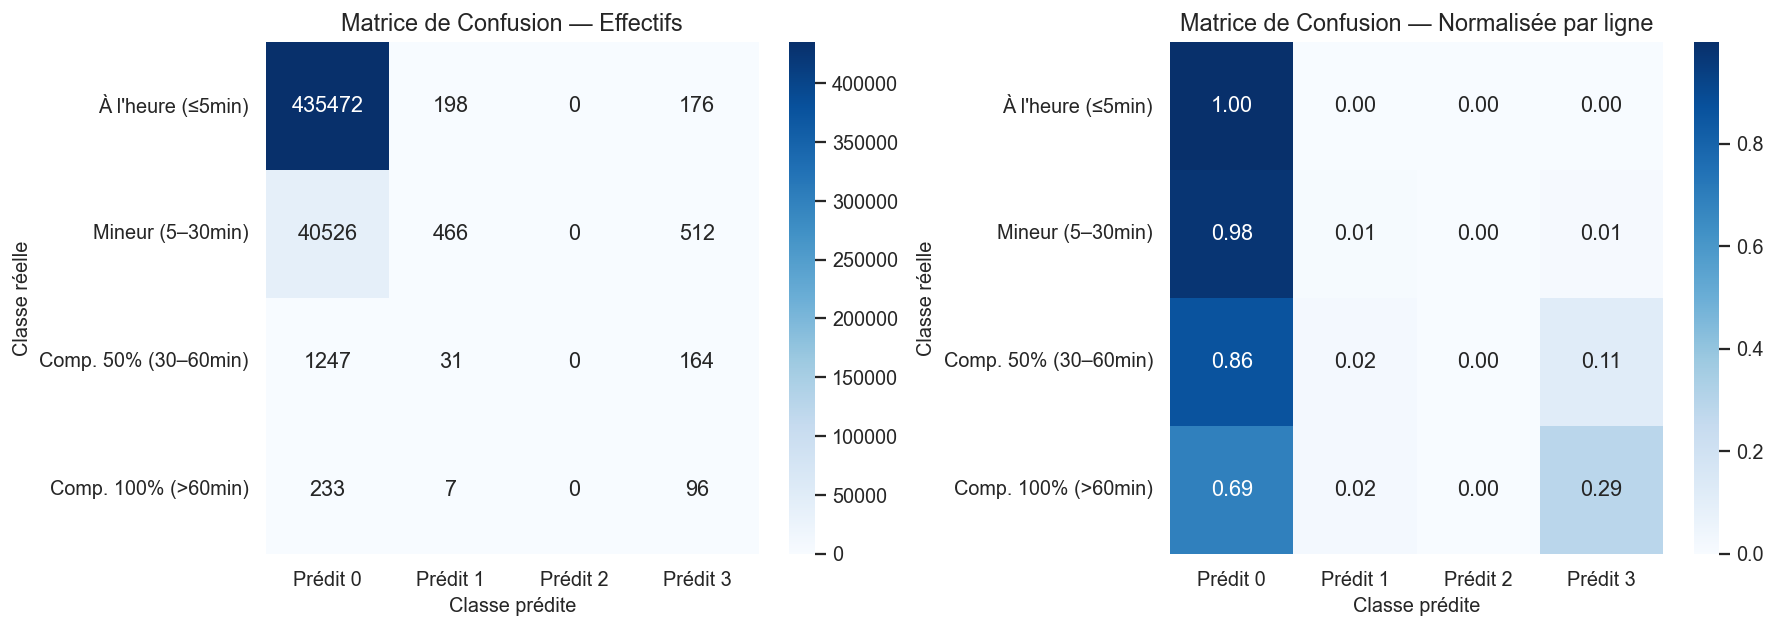

In [20]:
cm = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'Prédit {i}' for i in range(4)],
            yticklabels=[CLASS_LABELS[i] for i in range(4)])
axes[0].set_title('Matrice de Confusion — Effectifs')
axes[0].set_ylabel('Classe réelle')
axes[0].set_xlabel('Classe prédite')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=[f'Prédit {i}' for i in range(4)],
            yticklabels=[CLASS_LABELS[i] for i in range(4)])
axes[1].set_title('Matrice de Confusion — Normalisée par ligne')
axes[1].set_ylabel('Classe réelle')
axes[1].set_xlabel('Classe prédite')

plt.tight_layout()
plt.savefig('lgbm_confusion_matrix.png', bbox_inches='tight')
plt.show()

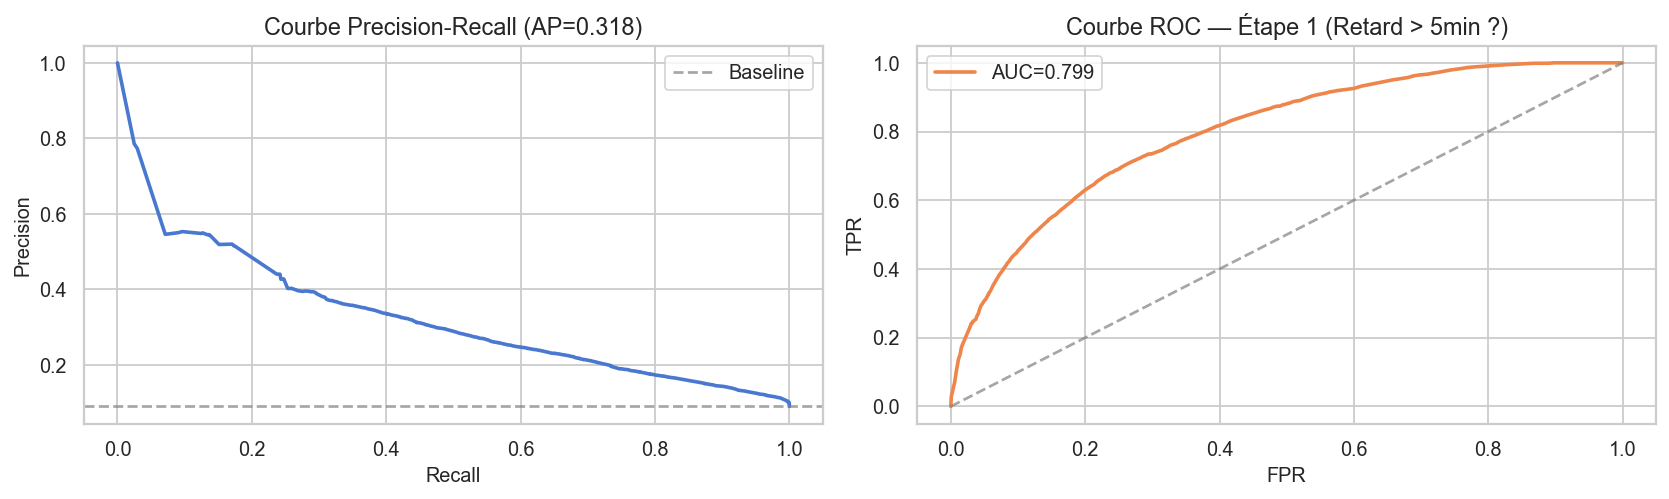

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

prec_arr, rec_arr, _ = precision_recall_curve(y_test_s1, proba_test_s1)
axes[0].plot(rec_arr, prec_arr, color=PALETTE[0], lw=2)
axes[0].axhline(y_test_s1.mean(), color='gray', linestyle='--', alpha=0.7, label='Baseline')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'Courbe Precision-Recall (AP={ap_binary:.3f})')
axes[0].legend()

fpr, tpr, _ = roc_curve(y_test_s1, proba_test_s1)
axes[1].plot(fpr, tpr, color=PALETTE[1], lw=2, label=f'AUC={auc_binary:.3f}')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--', alpha=0.7)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('Courbe ROC — Étape 1 (Retard > 5min ?)')
axes[1].legend()

plt.tight_layout()
plt.savefig('lgbm_pr_roc.png', bbox_inches='tight')
plt.show()

---
## 15. Évaluation Financière (Barèmes NS réels)

**Logique d'évaluation :**
- **Faux Négatif classe 2** → compensation 50% du billet non provisionnée
- **Faux Négatif classe 3** → compensation 100% du billet non provisionnée
- **Faux Positif** → coût opérationnel de l'alerte

La **baseline naïve** prédit toujours classe 0 → c'est le coût maximal sans modèle.

In [22]:
cost_model   = business_cost(y_test, y_test_pred)
cost_naive_v = naive_cost(y_test)
saving       = cost_naive_v - cost_model
saving_pct   = saving / cost_naive_v * 100

test_days    = (df_test['Service:Date'].max() - df_test['Service:Date'].min()).days + 1
annual_scale = 365 / max(test_days, 1)

print('═'*72)
print('  LGBM CASCADE — ÉVALUATION FINANCIÈRE (TEST SET)')
print('  Barèmes NS : 50% billet si 30-59min | 100% billet si ≥60min')
print('═'*72)
print(f'  Prix moyen billet utilisé        : €{AVG_TICKET:.2f}')
print(f'  Compensation moyenne cl.2 (50%)  : €{COMP_50:,.0f} / service')
print(f'  Compensation moyenne cl.3 (100%) : €{COMP_100:,.0f} / service')
print('─'*72)
print(f'  Coût modèle LGBM     : €{cost_model:>12,.0f}')
print(f'  Baseline naïve       : €{cost_naive_v:>12,.0f}')
arrow = '↓ ÉCONOMIE ✓' if saving > 0 else '↑ SURCOÛT ✗'
print(f'  Économie réalisée    : €{saving:>+12,.0f}  ({saving_pct:.1f}%)  {arrow}')
print(f'  Période test         : {test_days} jours')
print(f'  Économie annualisée  : €{saving * annual_scale:>+12,.0f}')
print('─'*72)

fn_c2 = ((y_test==2) & (y_test_pred < 2)).sum()
fn_c3 = ((y_test==3) & (y_test_pred < 3)).sum()
fp_all = ((y_test_pred > y_test)).sum()
print()
print('Détail des erreurs coûteuses :')
print(f'  FN classe 2 (30-60 min non détecté) : {fn_c2:,}  → €{fn_c2*COMP_50:,.0f} non provisionnés')
print(f'  FN classe 3 (>60 min non détecté)   : {fn_c3:,}  → €{fn_c3*COMP_100:,.0f} non provisionnés')
print(f'  FP total    (alertes inutiles)       : {fp_all:,}  → €{fp_all*FP_COST:,.0f} de coûts opérationnels')

════════════════════════════════════════════════════════════════════════
  LGBM CASCADE — ÉVALUATION FINANCIÈRE (TEST SET)
  Barèmes NS : 50% billet si 30-59min | 100% billet si ≥60min
════════════════════════════════════════════════════════════════════════
  Prix moyen billet utilisé        : €16.07
  Compensation moyenne cl.2 (50%)  : €482 / service
  Compensation moyenne cl.3 (100%) : €964 / service
────────────────────────────────────────────────────────────────────────
  Coût modèle LGBM     : €     900,018
  Baseline naïve       : €   1,019,143
  Économie réalisée    : €    +119,125  (11.7%)  ↓ ÉCONOMIE ✓
  Période test         : 353 jours
  Économie annualisée  : €    +123,174
────────────────────────────────────────────────────────────────────────

Détail des erreurs coûteuses :
  FN classe 2 (30-60 min non détecté) : 1,278  → €616,114 non provisionnés
  FN classe 3 (>60 min non détecté)   : 240  → €231,404 non provisionnés
  FP total    (alertes inutiles)       : 1,050  → €52,

---
## 16. Feature Importance (LightGBM)

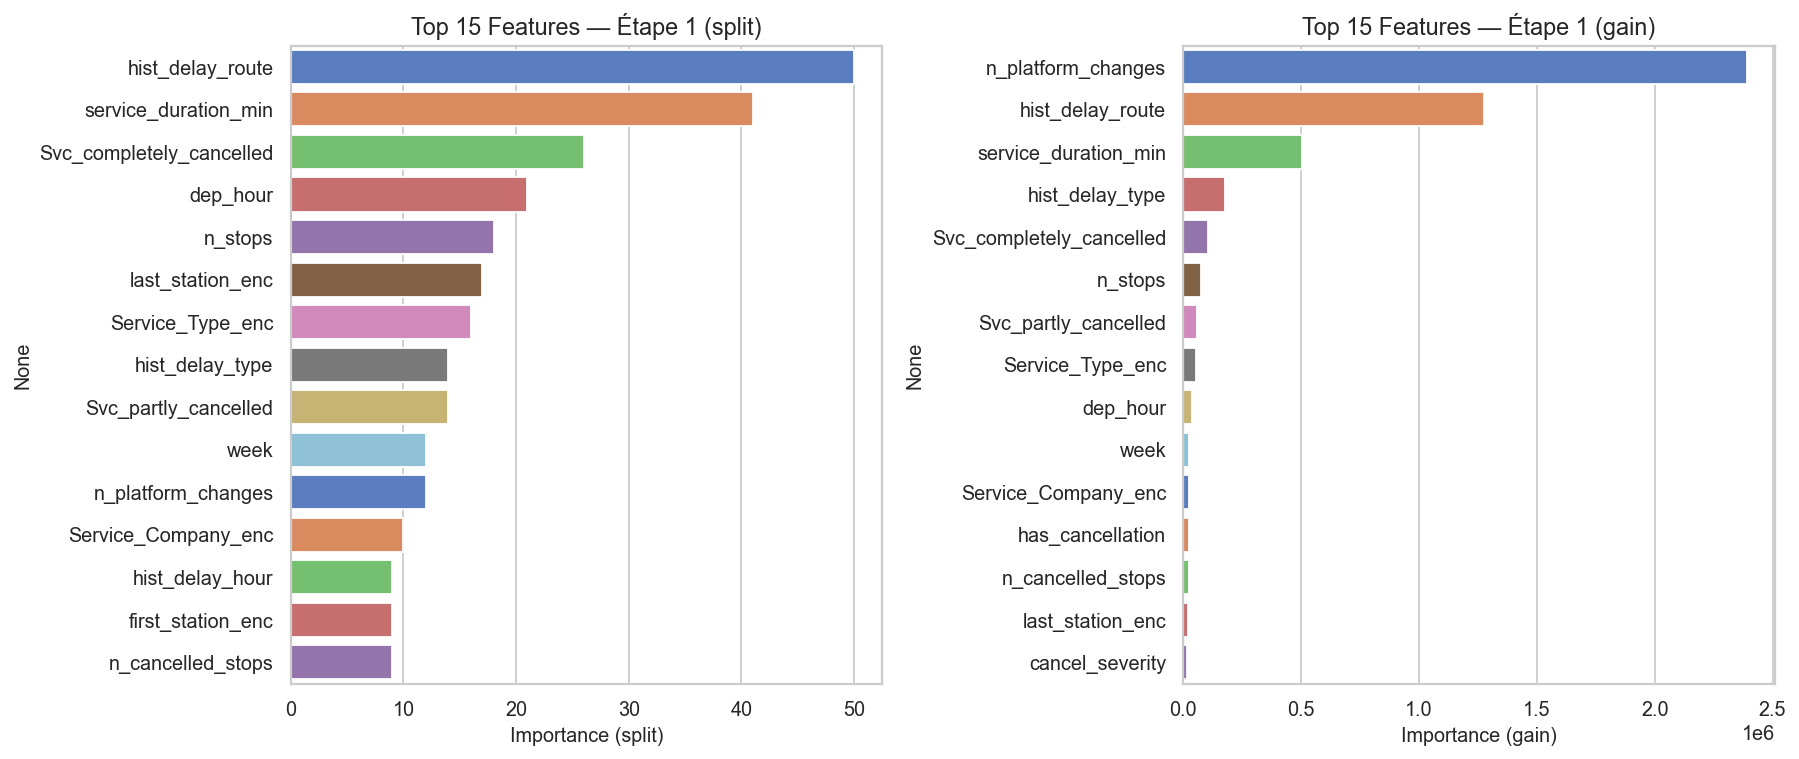

Top 10 features (gain) :
  n_platform_changes                  : 2,389,717
  hist_delay_route                    : 1,274,864
  service_duration_min                : 501,715
  hist_delay_type                     : 177,985
  Svc_completely_cancelled            : 103,319
  n_stops                             : 76,008
  Svc_partly_cancelled                : 58,009
  Service_Type_enc                    : 55,055
  dep_hour                            : 36,812
  week                                : 25,823


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, imp_type in zip(axes, ['split', 'gain']):
    fi = pd.Series(
        model_s1.booster_.feature_importance(importance_type=imp_type),
        index=FEATURES
    ).sort_values(ascending=False)
    sns.barplot(x=fi.values[:15], y=fi.index[:15], palette='muted', orient='h', ax=ax)
    ax.set_title(f'Top 15 Features — Étape 1 ({imp_type})')
    ax.set_xlabel(f'Importance ({imp_type})')

plt.tight_layout()
plt.savefig('lgbm_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 10 features (gain) :')
fi_gain = pd.Series(
    model_s1.booster_.feature_importance(importance_type='gain'),
    index=FEATURES
).sort_values(ascending=False)
for feat, imp in fi_gain.head(10).items():
    print(f'  {feat:<35} : {imp:,.0f}')